## 05 — Train Triage Severity Classifier

Target: **Patient Outcome** — binary classification (0 = Discharged, 1 = Admitted)  
Models compared: Logistic Regression (baseline) → Random Forest → XGBoost (tuned)  
Metrics: Accuracy, AUC-ROC, Precision, Recall, F1

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_score, GridSearchCV
from xgboost import XGBClassifier

from feature_engineering import prepare_with_features

plt.style.use('dark_background')
ACCENT  = '#3b82f6'
SUCCESS = '#22c55e'
DANGER  = '#ef4444'
PALETTE = [ACCENT, SUCCESS, '#f97316', '#a855f7']
print('Libraries loaded')

Libraries loaded


### 1. Load Data & Class Balance Check

Training samples : 4000
Test samples     : 1000
Features         : 16

Class distribution (train):
  Discharged (0): 2506  (62.6%)
  Admitted   (1): 1494  (37.4%)


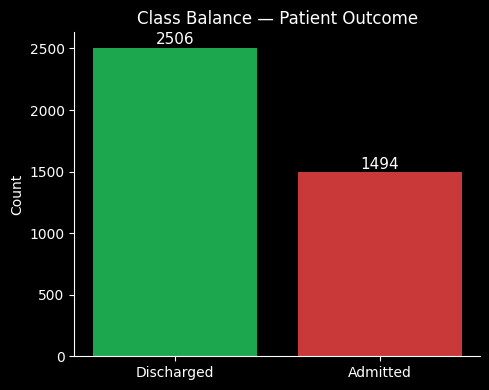

In [2]:
splits = prepare_with_features()
X_train = splits['X_train']
X_test  = splits['X_test']
y_train = splits['y_outcome_train']
y_test  = splits['y_outcome_test']
feature_names = splits['feature_names']

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {len(feature_names)}')

# Class distribution
train_counts = y_train.value_counts()
print(f'\nClass distribution (train):')
print(f'  Discharged (0): {train_counts.get(0, 0)}  ({train_counts.get(0,0)/len(y_train)*100:.1f}%)')
print(f'  Admitted   (1): {train_counts.get(1, 0)}  ({train_counts.get(1,0)/len(y_train)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(5, 4))
labels = ['Discharged', 'Admitted']
counts = [train_counts.get(0, 0), train_counts.get(1, 0)]
bars = ax.bar(labels, counts, color=[SUCCESS, DANGER], alpha=0.85)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', va='bottom', color='white', fontsize=11)
ax.set_ylabel('Count', color='white')
ax.set_title('Class Balance — Patient Outcome', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 2. Baseline — Logistic Regression

In [3]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

acc_lr = accuracy_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f'Logistic Regression  →  Accuracy: {acc_lr:.4f}  AUC: {auc_lr:.4f}')

Logistic Regression  →  Accuracy: 0.6260  AUC: 0.4778


### 3. Random Forest Classifier

In [4]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

acc_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f'Random Forest  →  Accuracy: {acc_rf:.4f}  AUC: {auc_rf:.4f}')

Random Forest  →  Accuracy: 0.5950  AUC: 0.5311


### 4. XGBoost Classifier

In [5]:
xgb = XGBClassifier(n_estimators=300, random_state=42, n_jobs=-1, verbosity=0, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

acc_xgb = accuracy_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f'XGBoost (default)  →  Accuracy: {acc_xgb:.4f}  AUC: {auc_xgb:.4f}')

XGBoost (default)  →  Accuracy: 0.5730  AUC: 0.5205


### 5. Cross-Validation Comparison (AUC)

LogisticRegression      CV AUC: 0.4915 ± 0.0190
RandomForest            CV AUC: 0.4901 ± 0.0162
XGBoost                 CV AUC: 0.4885 ± 0.0145


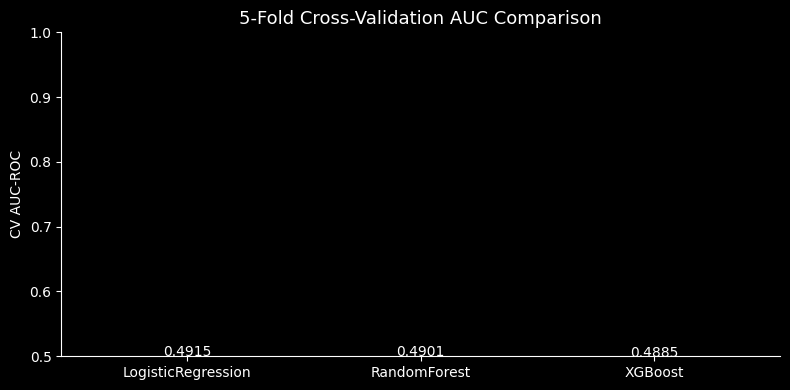

In [6]:
models_cv = {
    'LogisticRegression': lr,
    'RandomForest': rf,
    'XGBoost': xgb,
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train, y_train, cv=5,
                             scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22}  CV AUC: {scores.mean():.4f} ± {scores.std():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
names = list(cv_results.keys())
means = [cv_results[n].mean() for n in names]
stds  = [cv_results[n].std()  for n in names]
bars = ax.bar(names, means, color=PALETTE[:3], yerr=stds, capsize=5, alpha=0.85)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('CV AUC-ROC', color='white')
ax.set_title('5-Fold Cross-Validation AUC Comparison', color='white', fontsize=13)
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', color='white', fontsize=10)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 6. Hyperparameter Tuning — XGBoost GridSearchCV

In [7]:
param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
}

grid_search = GridSearchCV(
    XGBClassifier(random_state=42, n_jobs=-1, verbosity=0, eval_metric='logloss'),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)

print('\nBest Parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV AUC: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best Parameters:
  learning_rate: 0.1
  max_depth: 6
  n_estimators: 300
  subsample: 1.0

Best CV AUC: 0.4827


### 7. Final Model Evaluation

In [8]:
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

acc_best = accuracy_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_prob_best)

summary = pd.DataFrame({
    'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost (default)', 'XGBoost (tuned)'],
    'Accuracy': [acc_lr, acc_rf, acc_xgb, acc_best],
    'AUC-ROC':  [auc_lr, auc_rf, auc_xgb, auc_best],
})
summary = summary.sort_values('AUC-ROC', ascending=False)
summary[['Accuracy','AUC-ROC']] = summary[['Accuracy','AUC-ROC']].round(4)
print(summary.to_string(index=False))

print('\n--- Classification Report (XGBoost tuned) ---')
print(classification_report(y_test, y_pred_best, target_names=['Discharged', 'Admitted']))

              Model  Accuracy  AUC-ROC
    XGBoost (tuned)     0.580   0.5320
      Random Forest     0.595   0.5311
  XGBoost (default)     0.573   0.5205
Logistic Regression     0.626   0.4778

--- Classification Report (XGBoost tuned) ---
              precision    recall  f1-score   support

  Discharged       0.63      0.79      0.70       626
    Admitted       0.40      0.23      0.29       374

    accuracy                           0.58      1000
   macro avg       0.51      0.51      0.50      1000
weighted avg       0.54      0.58      0.55      1000



### 8. Confusion Matrix

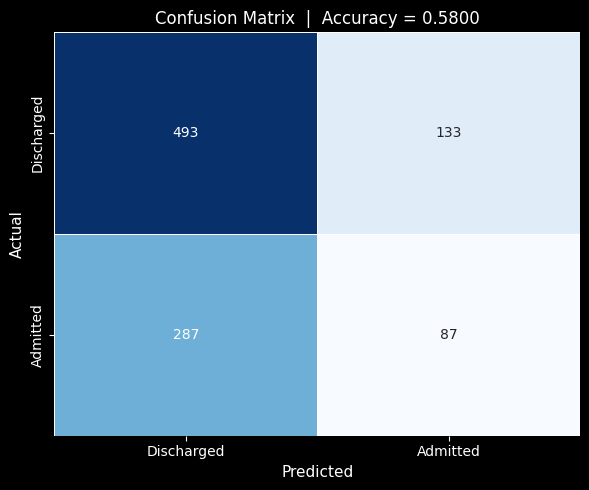

True Negatives  (Correctly discharged): 493
False Positives (Admitted wrongly)     : 133
False Negatives (Missed admissions)    : 287
True Positives  (Correctly admitted)   : 87


In [9]:
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Discharged', 'Admitted'],
    yticklabels=['Discharged', 'Admitted'],
    ax=ax, linewidths=0.5, cbar=False
)
ax.set_xlabel('Predicted', color='white', fontsize=11)
ax.set_ylabel('Actual', color='white', fontsize=11)
ax.set_title(f'Confusion Matrix  |  Accuracy = {acc_best:.4f}', color='white', fontsize=12)
ax.tick_params(colors='white')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives  (Correctly discharged): {tn}')
print(f'False Positives (Admitted wrongly)     : {fp}')
print(f'False Negatives (Missed admissions)    : {fn}')
print(f'True Positives  (Correctly admitted)   : {tp}')

### 9. ROC Curve

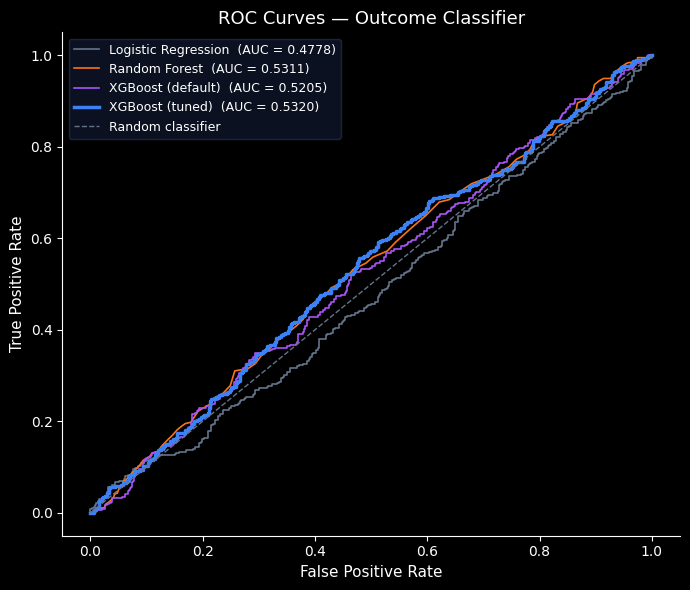

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

for name, y_prob, color in [
    ('Logistic Regression', y_prob_lr,  '#64748b'),
    ('Random Forest',       y_prob_rf,  '#f97316'),
    ('XGBoost (default)',   y_prob_xgb, '#a855f7'),
    ('XGBoost (tuned)',     y_prob_best, ACCENT),
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    lw = 2.5 if 'tuned' in name else 1.2
    ax.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.4f})', color=color, linewidth=lw)

ax.plot([0,1],[0,1], '--', color='#64748b', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', color='white', fontsize=11)
ax.set_ylabel('True Positive Rate', color='white', fontsize=11)
ax.set_title('ROC Curves — Outcome Classifier', color='white', fontsize=13)
ax.legend(facecolor='#0f1629', edgecolor='#1e2d4a', labelcolor='white', fontsize=9)
ax.tick_params(colors='white')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

### 10. Feature Importance

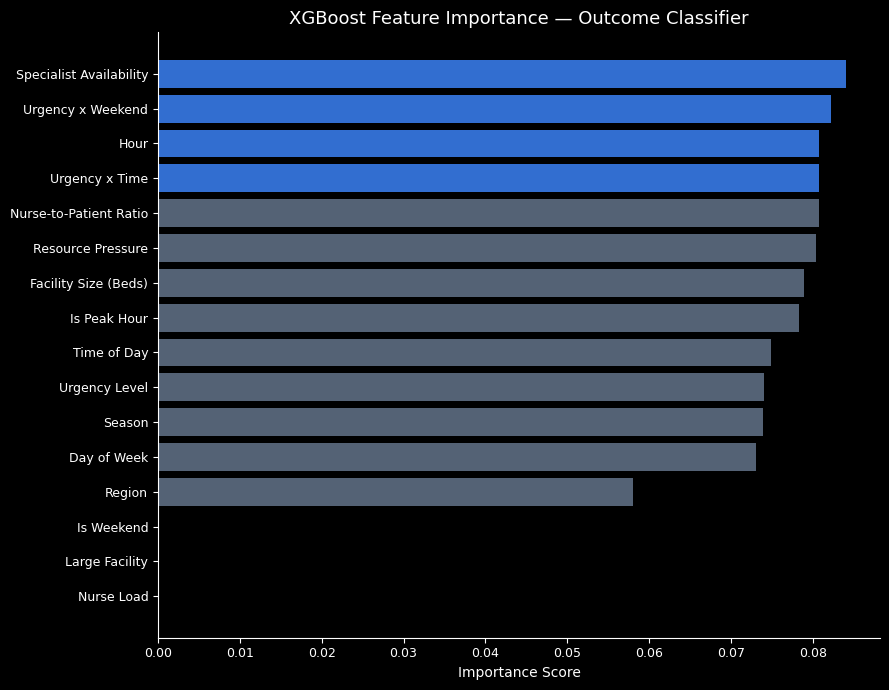

Top 5 features:
                feature  importance
Specialist Availability    0.084013
      Urgency x Weekend    0.082204
                   Hour    0.080782
         Urgency x Time    0.080731
 Nurse-to-Patient Ratio    0.080723


In [11]:
importances = best_model.feature_importances_
fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
colors = [ACCENT if imp > fi_df['importance'].quantile(0.75) else '#64748b' for imp in fi_df['importance']]
ax.barh(fi_df['feature'], fi_df['importance'], color=colors, alpha=0.85)
ax.set_xlabel('Importance Score', color='white')
ax.set_title('XGBoost Feature Importance — Outcome Classifier', color='white', fontsize=13)
ax.tick_params(colors='white', labelsize=9)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(fi_df.sort_values('importance', ascending=False).head(5).to_string(index=False))

### 11. Save Best Model

In [12]:
models_dir = os.path.join('..', 'models')
os.makedirs(models_dir, exist_ok=True)

save_path = os.path.join(models_dir, 'outcome_model.pkl')
joblib.dump({'model': best_model, 'feature_names': feature_names}, save_path)

print(f'Model saved: {save_path}')
print(f'\n--- Final Metrics ---')
print(f'Accuracy : {acc_best:.4f}')
print(f'AUC-ROC  : {auc_best:.4f}')
print(f'\nFeatures used: {len(feature_names)}')

Model saved: ..\models\outcome_model.pkl

--- Final Metrics ---
Accuracy : 0.5800
AUC-ROC  : 0.5320

Features used: 16
